# Análisis exploratorio de datos

Contentesta las siguientes preguntas escribiendo el código de Python necesario para encontrar las respuestas o producir las gráficas necesarias

---


In [1]:
# No mostrar advertencias
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/retailmax.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


### 1. ¿Cuál es la distribución de edades de los clientes?
- **Objetivo**: Comprender la distribución de las edades en el conjunto de datos.
- **Respuesta esperada**: Un histograma de la columna Age.

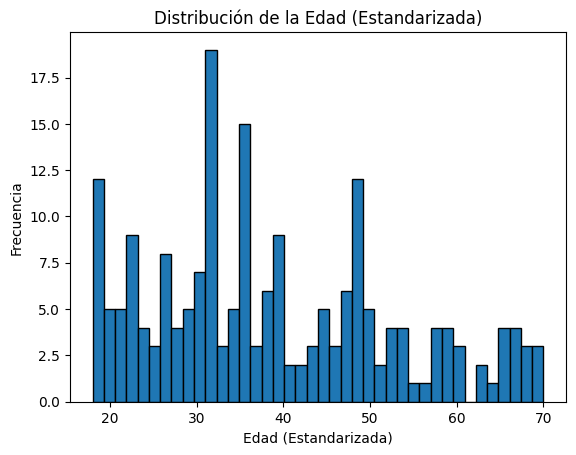

In [4]:
plt.hist(df['Age'], bins=40, edgecolor='black')
plt.title('Distribución de la Edad (Estandarizada)')
plt.xlabel('Edad (Estandarizada)')
plt.ylabel('Frecuencia')
plt.show()

### 2. ¿Existen diferencias significativas en los ingresos anuales entre hombres y mujeres?
- **Objetivo**: Comparar la distribución de ingresos anuales entre géneros.
- **Respuesta esperada**: Una gráfica de cajas (boxplot) que muestre la distribución de Annual Income (k$) por género.

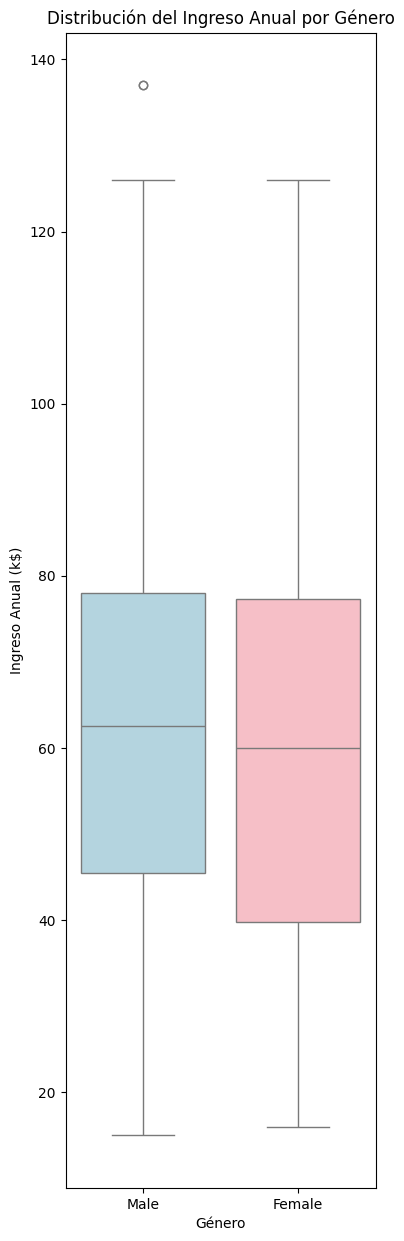

In [5]:
plt.figure(figsize=(4, 15))
sns.boxplot(data=df, x='Gender', y='Annual Income (k$)', palette=['lightblue', 'lightpink'])
plt.title('Distribución del Ingreso Anual por Género')
plt.xlabel('Género')
plt.ylabel('Ingreso Anual (k$)')
plt.show()

### 3. ¿Cómo se distribuye la puntuación de gasto (Spending Score) entre los diferentes rangos de edad?
- **Objetivo**: Analizar la relación entre la edad y la puntuación de gasto.
- **Respuesta esperada**: Una gráfica de dispersión (scatter plot) o un gráfico de cajas que compare la Spending Score (1-100) con diferentes grupos de edad.

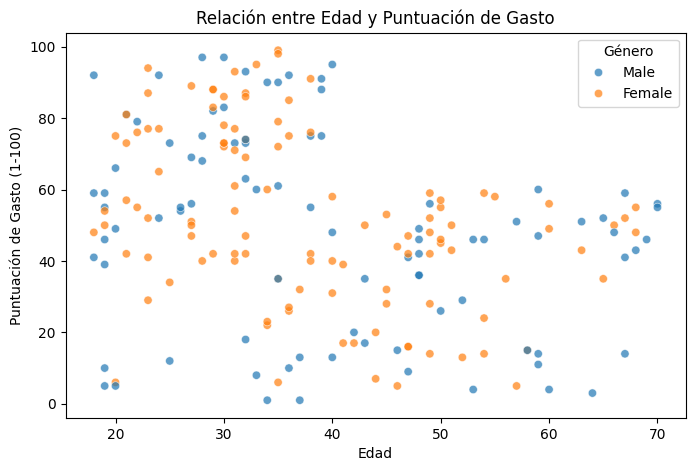

In [8]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Age", y="Spending Score (1-100)", hue="Gender", alpha=0.7)
plt.title("Relación entre Edad y Puntuación de Gasto")
plt.xlabel("Edad")
plt.ylabel("Puntuación de Gasto (1-100)")
plt.legend(title="Género")
plt.show()

### 4. ¿Cuál es la correlación entre el ingreso anual y la puntuación de gasto?
- **Objetivo**: Identificar si existe una relación lineal entre el ingreso y el gasto.
- **Respuesta esperada**: Una gráfica de dispersión y el cálculo del coeficiente de correlación entre Annual Income (k$) y Spending Score (1-100).

Coeficiente de correlación: 0.010


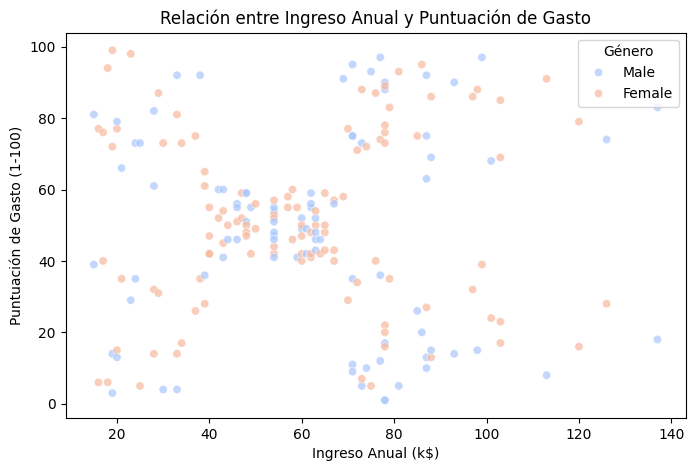

In [ ]:
#Cálculo del coeficiente de correlación
correlacion = df["Annual Income (k$)"].corr(df["Spending Score (1-100)"])
print(f"Coeficiente de correlación: {correlacion:.3f}")

#Gráfica de dispersión
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Gender",  #Vemos las diferencias por género
    palette="coolwarm",
    alpha=0.7
)
plt.title("Relación entre Ingreso Anual y Puntuación de Gasto")
plt.xlabel("Ingreso Anual (k$)")
plt.ylabel("Puntuación de Gasto (1-100)")
plt.legend(title="Género")
plt.show()

### 5. ¿Cómo varía la puntuación de gasto en diferentes grupos de ingresos anuales?
- **Objetivo**: Examinar cómo los clientes en diferentes rangos de ingresos se comportan en términos de gasto.
- **Respuesta esperada**: Una gráfica de cajas o de violín que muestre la Spending Score (1-100) para diferentes rangos de Annual Income (k$).

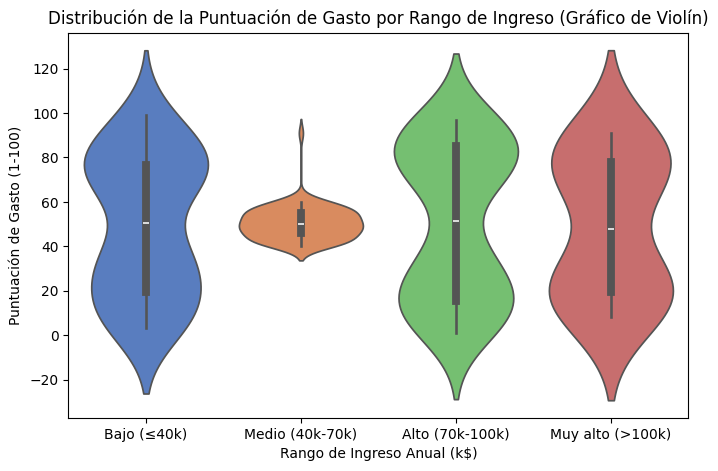

In [10]:
#Rangos de ingreso anual
bins = [0, 40, 70, 100, 140]
labels = ['Bajo (≤40k)', 'Medio (40k-70k)', 'Alto (70k-100k)', 'Muy alto (>100k)']
df['Income Range'] = pd.cut(df['Annual Income (k$)'], bins=bins, labels=labels, right=False)

#Gráfica de violín
plt.figure(figsize=(8,5))
sns.violinplot(
    data=df,
    x='Income Range',
    y='Spending Score (1-100)',
    palette='muted'
)
plt.title('Distribución de la Puntuación de Gasto por Rango de Ingreso (Gráfico de Violín)')
plt.xlabel('Rango de Ingreso Anual (k$)')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.show()

### 6. ¿Cuál es la proporción de clientes por género?
- **Objetivo**: Determinar el balance de género en el conjunto de datos.
- **Respuesta esperada**: Una gráfica de barras o un gráfico de pastel que muestre la proporción de hombres y mujeres.

Conteo por género:
Gender
Female    112
Male       88
Name: count, dtype: int64

Porcentaje por género:
Gender
Female    56.0
Male      44.0
Name: proportion, dtype: float64


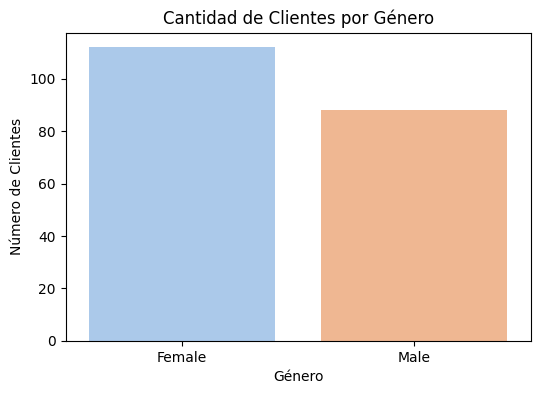

In [12]:
#Calculamos las proporciones
genero_counts = df['Gender'].value_counts()
genero_porcentaje = df['Gender'].value_counts(normalize=True) * 100

print("Conteo por género:")
print(genero_counts)
print("\nPorcentaje por género:")
print(genero_porcentaje.round(2))

#Gráfica de barras
plt.figure(figsize=(6,4))
sns.barplot(x=genero_counts.index, y=genero_counts.values, palette="pastel")
plt.title("Cantidad de Clientes por Género")
plt.xlabel("Género")
plt.ylabel("Número de Clientes")
plt.show()

### 7. ¿Qué grupos de edad gastan más en promedio?
- **Objetivo**: Identificar los grupos de edad que tienen una mayor puntuación de gasto en promedio.
- **Respuesta esperada**: Una gráfica de barras que compare la puntuación de gasto promedio entre diferentes grupos de edad.

  Age Range  Spending Score (1-100)
0     18-25               56.257143
1     26-35               63.166667
2     36-45               49.428571
3     46-55               36.230769
4     56-65               32.312500
5       66+               46.714286


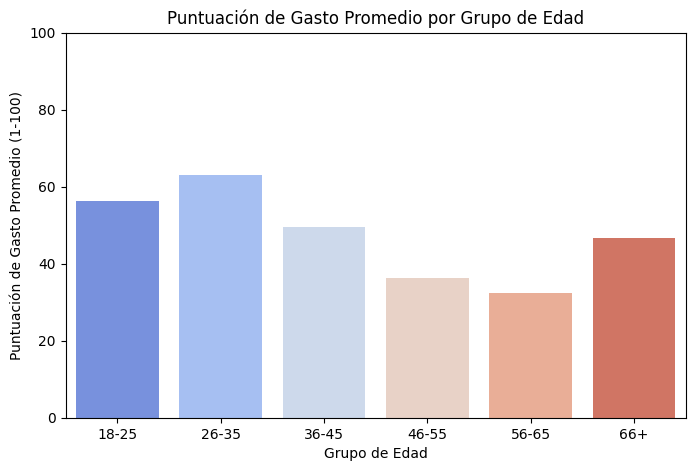

In [13]:
#Creamos los rangos de edad
bins = [18, 25, 35, 45, 55, 65, 80]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
df['Age Range'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

#Calculamos el gasto promedio por rango de edad
age_spending = df.groupby('Age Range')['Spending Score (1-100)'].mean().reset_index()

print(age_spending)

#Gráfico de barras
plt.figure(figsize=(8,5))
sns.barplot(
    data=age_spending,
    x='Age Range',
    y='Spending Score (1-100)',
    palette='coolwarm'
)
plt.title('Puntuación de Gasto Promedio por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Puntuación de Gasto Promedio (1-100)')
plt.ylim(0, 100)
plt.show()

### 8. ¿Hay alguna relación entre la edad y el ingreso anual de los clientes?
- **Objetivo**: Explorar si hay una tendencia entre la edad de los clientes y sus ingresos.
- **Respuesta esperada**: Una gráfica de dispersión que muestre la relación entre Age y Annual Income (k$).

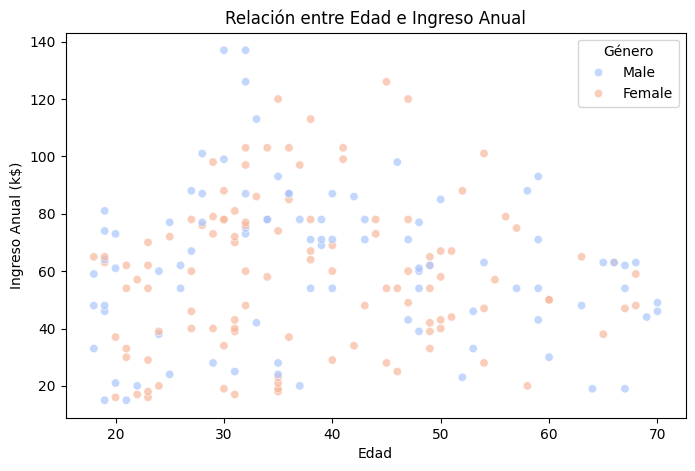

In [14]:
#Gráfica de dispersión
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Age',
    y='Annual Income (k$)',
    hue='Gender', 
    palette='coolwarm',
    alpha=0.7
)
plt.title('Relación entre Edad e Ingreso Anual')
plt.xlabel('Edad')
plt.ylabel('Ingreso Anual (k$)')
plt.legend(title='Género')
plt.show()

### 9. ¿Cuál es la distribución conjunta de la edad y el ingreso anual?
- **Objetivo**: Entender cómo se distribuyen estas dos variables en conjunto.
- **Respuesta esperada**: Una gráfica de dispersión con una densidad de puntos o un gráfico de hexágonos que muestre la distribución conjunta de Age y Annual Income (k$).

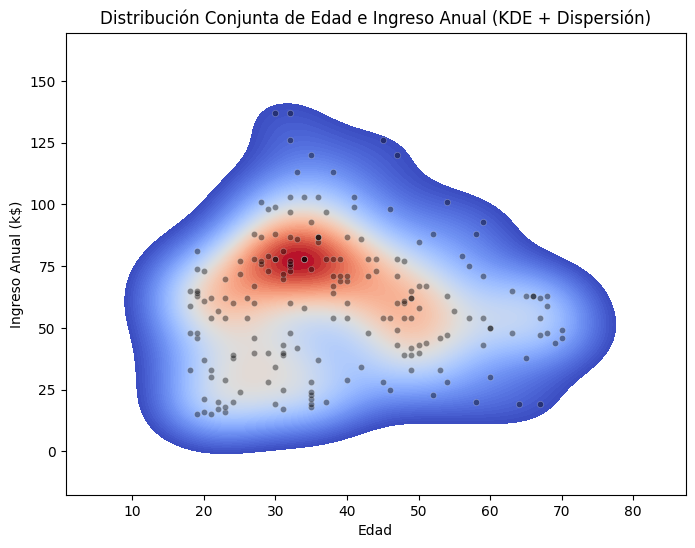

In [15]:
#Gráfico de dispersión con densidad de puntos
plt.figure(figsize=(8,6))
sns.kdeplot(
    data=df,
    x="Age",
    y="Annual Income (k$)",
    fill=True,
    cmap="coolwarm",
    thresh=0.05,
    levels=100
)
sns.scatterplot(
    data=df,
    x="Age",
    y="Annual Income (k$)",
    color="black",
    alpha=0.4,
    s=20
)
plt.title("Distribución Conjunta de Edad e Ingreso Anual (KDE + Dispersión)")
plt.xlabel("Edad")
plt.ylabel("Ingreso Anual (k$)")
plt.show()

### 10. ¿Cómo se distribuyen los clientes en función de la puntuación de gasto y el género?
- **Objetivo**: Analizar la relación entre la puntuación de gasto y el género.
- **Respuesta esperada**: Una gráfica de dispersión o un gráfico de violín que muestre la Spending Score (1-100) separada por género.

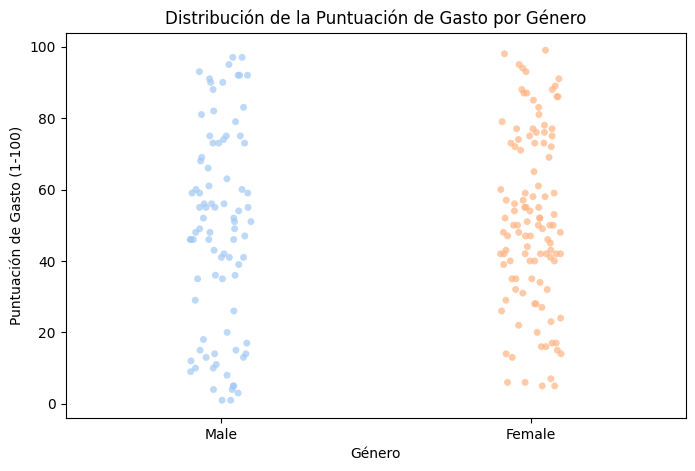

In [16]:
#Gráfico de dispersión (simple, por género)
plt.figure(figsize=(8,5))
sns.stripplot(
    data=df,
    x='Gender',
    y='Spending Score (1-100)',
    jitter=True,        # dispersa los puntos para evitar superposición
    alpha=0.7,
    palette='pastel'
)
plt.title('Distribución de la Puntuación de Gasto por Género')
plt.xlabel('Género')
plt.ylabel('Puntuación de Gasto (1-100)')
plt.show()